In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
from collections import Counter
from sklearn import model_selection, naive_bayes, svm, metrics, feature_extraction
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [17]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [18]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [19]:
df.isna().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [23]:
count1 = Counter(" ".join(df[df['v1']=='ham']['v2']).split()).most_common(10)
df1 = pd.DataFrame.from_dict(count1)
df1 = df1.rename(columns={0: "words in no-spam", 1: "count"})

count2 = Counter(" ".join(df[df['v1']=='ham']['v2']).split()).most_common(10)
df2 = pd.DataFrame.from_dict(count2)
df2 = df2.rename(columns={0: "words in spam", 1: "count_"})

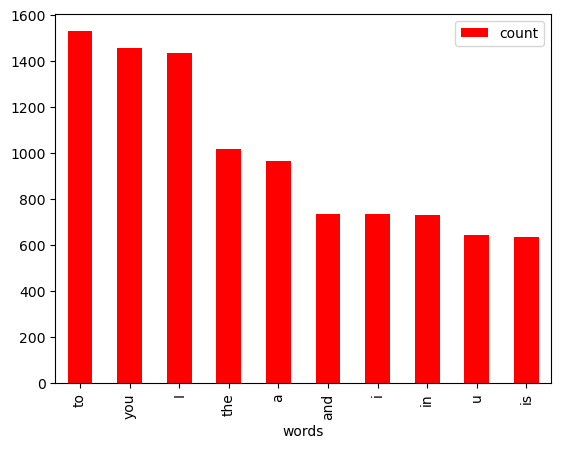

In [24]:
df1.plot.bar(color='red')
y_p = np.arange(len(df1["words in no-spam"]))
plt.xticks(y_p, df1["words in no-spam"])
plt.xlabel('words')
plt.show()

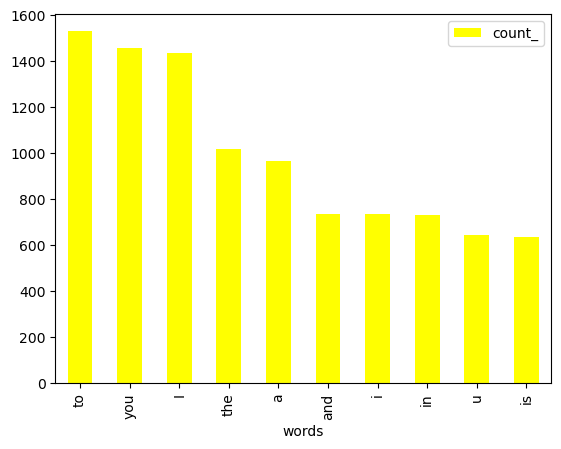

In [25]:
df2.plot.bar(color='yellow')
y_p = np.arange(len(df2["words in spam"]))
plt.xticks(y_p, df2["words in spam"])
plt.xlabel('words')
plt.show()

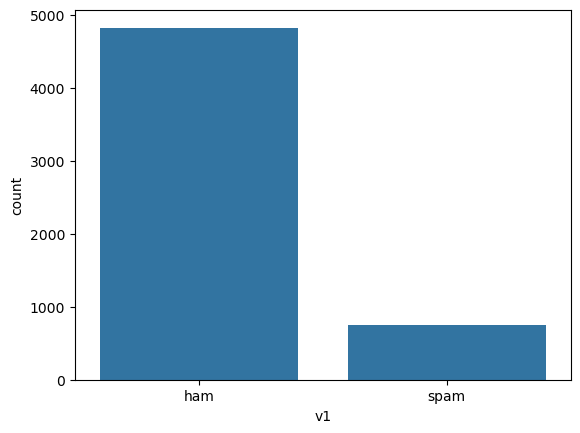

In [27]:
sns.countplot(data=df, x='v1');

In [28]:
#tfidf

# Feature Engineering
f = feature_extraction.text.CountVectorizer(stop_words='english')
x = f.fit_transform(df['v2'])
np.shape(x)

(5572, 8404)

In [29]:
df['v1'].unique()

array(['ham', 'spam'], dtype=object)

In [31]:
df['v1'] = df['v1'].map({'ham':0, 'spam':1})

In [34]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(x, df['v1'], test_size=0.2, random_state=42)

In [35]:
bayes = naive_bayes.MultinomialNB()

In [36]:
bayes.fit(x_train, y_train)

MultinomialNB()

In [37]:
y_pred = bayes.predict(x_test)

In [64]:
print(accuracy_score(y_test, y_pred)*100)

98.02690582959642


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.93      0.93      0.93       150

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [39]:
print(confusion_matrix(y_test, y_pred))

[[954  11]
 [ 11 139]]


In [45]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [72]:
svc_l = SVC(kernel='linear')
svc_s = SVC(kernel='sigmoid')
svc_p = SVC(kernel='poly')
svc_r = SVC(kernel='rbf')

In [73]:
svc_l.fit(x_train, y_train)

SVC(kernel='linear')

In [74]:
y_predsvc = svc_l.predict(x_test)

In [75]:
print(accuracy_score(y_test, y_predsvc)*100)

98.02690582959642


In [70]:
print(classification_report(y_test, y_predsvc))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       0.99      0.83      0.91       150

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [76]:
svc_s.fit(x_train, y_train)

SVC(kernel='sigmoid')

In [77]:
y_predsvcs = svc_s.predict(x_test)

In [79]:
print(accuracy_score(y_test, y_predsvcs)*100)

98.11659192825111


In [80]:
print(classification_report(y_test, y_predsvcs))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.87      0.93       150

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [51]:
knn = KNeighborsClassifier()

In [52]:
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [53]:
y_predknn = knn.predict(x_test)

In [62]:
print(accuracy_score(y_test, y_predknn)*100)

91.74887892376682


In [54]:
print(classification_report(y_test, y_predknn))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95       965
           1       1.00      0.39      0.56       150

    accuracy                           0.92      1115
   macro avg       0.96      0.69      0.76      1115
weighted avg       0.92      0.92      0.90      1115



In [50]:
lor = LogisticRegression()

In [55]:
lor.fit(x_train, y_train)

LogisticRegression()

In [57]:
y_predlor = lor.predict(x_test)

In [61]:
print(accuracy_score(y_test, y_predlor)*100)

97.847533632287


In [59]:
print(classification_report(y_test, y_predlor))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       1.00      0.84      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115

